# Why does the 2-triangle check catch subpixel folds that central differences miss?

The bowtie example (from `02_optimization.ipynb` and `09_horizontal-vs-diagonal-bowtie.ipynb`) is a 7×7 field with `dx[3,3] = +1.2`, `dx[3,4] = −1.2`, everything else zero. Two pixels swap horizontally, the cells between them collapse into a self-intersecting bowtie shape. Geometrically: **folded**. Yet:

- **Central-differences (CD) Jacobian** reports `min(Jdet) = +0.40`, all positive — *no folds detected*.
- **Two-triangle (2-tri) check** reports `min(T₁, T₂) = −0.70` on two cells — *fold caught*.

This notebook visualises *why* CD is blind to the bowtie and *why* 2-tri sees it. Five views, each one targeting a different part of the explanation:

1. **Stencil comparison.** CD samples 4 *neighbours* of a pixel (and explicitly skips the pixel itself); 2-tri samples all 4 *corners* of a cell. The pixel that triggers the fold (`dx[3,3] = +1.2`) is *not* in CD's stencil for pixel `(3,3)`.
2. **Heatmap comparison on the bowtie.** CD's Jdet map vs the 2-tri T₁ / T₂ / min(T₁, T₂) maps, side by side.
3. **Step-by-step computation** at the bowtie pixel: walk through the CD partial-derivative arithmetic that yields a positive Jdet, then walk through the 2-tri signed-area arithmetic that yields a negative T₁.
4. **The averaging problem in 1D.** Plot `dx` along row 3; show how CD's 2-pixel stride averages the `+1.2 → 0` slope and the `0 → −1.2` slope into the same `−0.6`, blunting the local extremum.
5. **The deformed-cell geometry.** Zoom into the bowtie cell, show the actual self-intersecting quad, and overlay the 2-tri diagonal so the negative-area triangle is visually obvious.

The takeaway through-line: **CD measures derivatives at neighbours, 2-tri measures the area of the actual deformed quad.** A subpixel fold — one where the displacement changes by more than the cell width inside a single cell — is invisible to CD's smoothing stencil but trivially visible to 2-tri's geometric check.

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Polygon
from matplotlib.lines import Line2D

from dvfopt import jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d

In [2]:
H = W = 7
phi = np.zeros((2, H, W))
phi[1, 3, 3] = +1.2  # phi[1] = dx
phi[1, 3, 4] = -1.2

jd_cd = np.squeeze(jacobian_det2D(phi))         # central-diff Jdet, shape (H, W)
T1, T2 = _triangle_areas_2d(phi[0], phi[1])      # per-cell triangle areas, each (H-1, W-1)
tri_min = np.minimum(T1, T2)

print(f'central-diff Jdet:   min = {jd_cd.min():+.3f},  n_neg = {int((jd_cd <= 0).sum())}')
print(f'two-triangle T1:      min = {T1.min():+.3f},  n_neg = {int((T1 <= 0).sum())}')
print(f'two-triangle T2:      min = {T2.min():+.3f},  n_neg = {int((T2 <= 0).sum())}')
print(f'min(T1, T2) per cell: min = {tri_min.min():+.3f},  n_neg = {int((tri_min <= 0).sum())}')

central-diff Jdet:   min = +0.400,  n_neg = 0
two-triangle T1:      min = -0.700,  n_neg = 1
two-triangle T2:      min = -0.700,  n_neg = 1
min(T1, T2) per cell: min = -0.700,  n_neg = 2


## 1. Stencil comparison

Each method's *stencil* is the set of pixels its result depends on.

**Central-differences Jacobian at pixel `(cy, cx)`** computes ∂dx/∂x, ∂dy/∂y, ∂dx/∂y, ∂dy/∂x using only the 4 cardinal neighbours `(cy±1, cx)` and `(cy, cx±1)`. The pixel `(cy, cx)` *itself* is **not** in any partial-derivative stencil. CD literally never reads the value at the pixel it's computing the Jdet for.

**Two-triangle check at cell `(cy, cx)`** uses all 4 corner pixels of the cell: `(cy, cx)`, `(cy, cx+1)`, `(cy+1, cx)`, `(cy+1, cx+1)`. Every pixel in the cell contributes to T₁ and T₂.

The figure below draws both stencils on a 5×5 zoom centred on the bowtie. Red ✗ = sampled but center-pixel skipped. Green ✓ = sampled. Grey · = ignored.

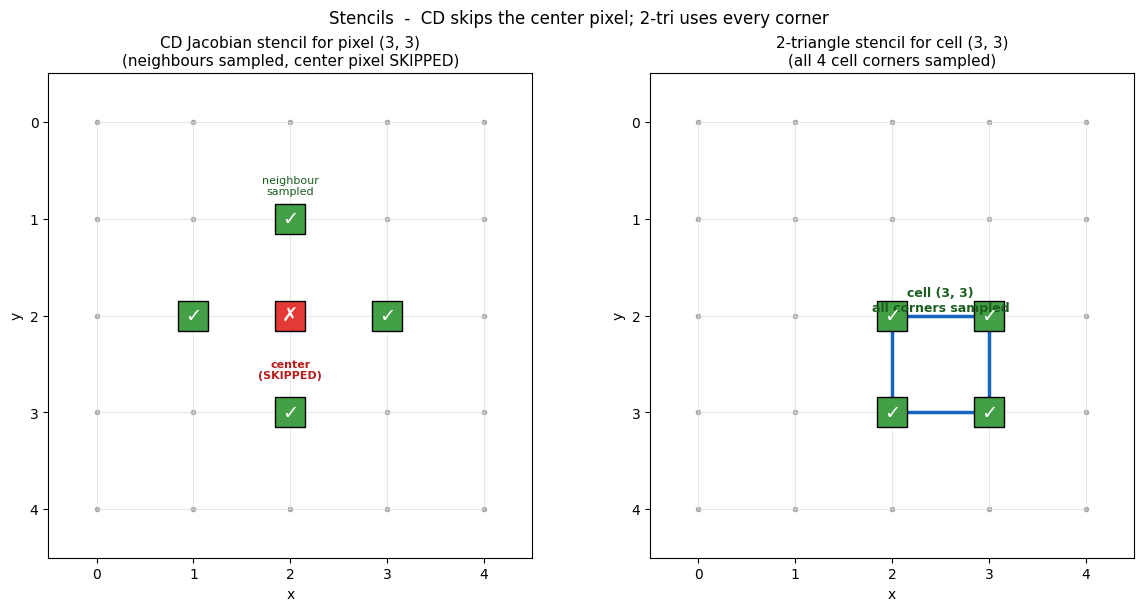


Key point: the bowtie sets dx[3,3] = +1.2 and dx[3,4] = -1.2.
When CD computes the Jdet at pixel (3,3), it samples dx at (3,2) and (3,4) (and dy at (2,3), (4,3)).
It does NOT see dx[3,3] = +1.2 itself - that bowtie value never enters the Jdet at (3,3).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout='constrained')

def draw_grid(ax, H, W, title):
    yy, xx = np.mgrid[:H, :W]
    for y in range(H):
        ax.plot([0, W-1], [y, y], color='#dddddd', lw=0.5)
    for x in range(W):
        ax.plot([x, x], [0, H-1], color='#dddddd', lw=0.5)
    for y in range(H):
        for x in range(W):
            ax.plot(x, y, 'o', color='#aaaaaa', markersize=3, zorder=1)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xlim(-0.5, W - 0.5); ax.set_ylim(H - 0.5, -0.5)
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title, fontsize=11)
    ax.grid(False)

# --- LEFT: CD stencil at pixel (3, 3) -------------------------------
ax = axes[0]
draw_grid(ax, 5, 5, 'CD Jacobian stencil for pixel (3, 3)\n'
                    '(neighbours sampled, center pixel SKIPPED)')
cy, cx = 2, 2  # within the 5x5 zoom this represents pixel (3,3) in absolute coords
# Center pixel - SKIPPED (the bowtie pixel)
ax.plot(cx, cy, 's', color='#e53935', markersize=22, zorder=3,
        markeredgecolor='black')
ax.text(cx, cy, '✗', ha='center', va='center', color='white', fontsize=14, weight='bold', zorder=4)
ax.text(cx, cy + 0.45, 'center\n(SKIPPED)', ha='center', va='top', fontsize=8,
        color='#b71c1c', weight='bold')
# Cardinal neighbours - SAMPLED
for (dy, dx) in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
    nx, ny = cx + dx, cy + dy
    ax.plot(nx, ny, 's', color='#43a047', markersize=22, zorder=3,
            markeredgecolor='black')
    ax.text(nx, ny, '✓', ha='center', va='center', color='white', fontsize=14, weight='bold', zorder=4)
ax.text(cx, cy - 1.45, 'neighbour\nsampled', ha='center', va='top', fontsize=8, color='#1b5e20')

# --- RIGHT: 2-tri stencil for cell (3, 3) ---------------------------
ax = axes[1]
draw_grid(ax, 5, 5, '2-triangle stencil for cell (3, 3)\n'
                    '(all 4 cell corners sampled)')
# Cell (3, 3) corners - within 5x5 zoom these are (2,2), (2,3), (3,2), (3,3)
for (vy, vx) in [(2, 2), (2, 3), (3, 2), (3, 3)]:
    ax.plot(vx, vy, 's', color='#43a047', markersize=22, zorder=3,
            markeredgecolor='black')
    ax.text(vx, vy, '✓', ha='center', va='center', color='white', fontsize=14, weight='bold', zorder=4)
# Outline the cell
ax.add_patch(Rectangle((2, 2), 1, 1, fill=False, edgecolor='#1565c0', lw=2.5, zorder=2))
ax.text(2.5, 1.7, 'cell (3, 3)\nall corners sampled', ha='center', va='top', fontsize=9,
        color='#1b5e20', weight='bold')

plt.suptitle('Stencils  -  CD skips the center pixel; 2-tri uses every corner',
             fontsize=12)
plt.show()

print('\nKey point: the bowtie sets dx[3,3] = +1.2 and dx[3,4] = -1.2.')
print('When CD computes the Jdet at pixel (3,3), it samples dx at (3,2) and (3,4) (and dy at (2,3), (4,3)).')
print('It does NOT see dx[3,3] = +1.2 itself - that bowtie value never enters the Jdet at (3,3).')

## 2. Bowtie heatmaps — what each method sees

The same 7×7 field, three views:

- **Warped grid** — shows the actual deformed mesh. Two cells fold (outlined dark blue).
- **CD Jdet** — uniformly red (positive). Minimum value `+0.40`; the method reports zero folds.
- **2-tri min(T₁, T₂)** — clearly blue on the two folded cells. Minimum value `−0.70`; both folds caught.

Both colour scales are symmetric so blue = negative = fold.

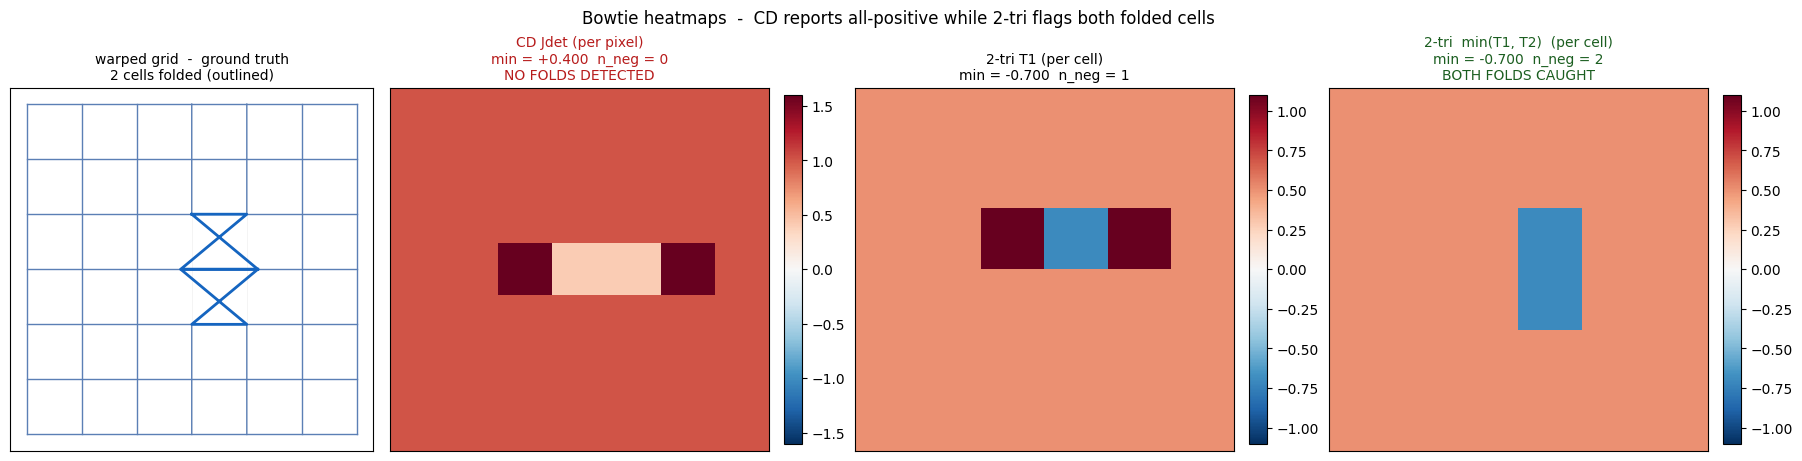

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), layout='constrained')

# --- Panel 1: warped grid -------------------------------------------
ax = axes[0]
yy, xx = np.mgrid[:H, :W]
gx = xx + phi[1]; gy = yy + phi[0]
for i in range(H):
    ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.5)
for j in range(W):
    ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.5)
for i in range(H):
    ax.plot(gx[i], gy[i], color='#5b7fb5', lw=1.0)
for j in range(W):
    ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=1.0)
for (cy, cx) in np.argwhere(tri_min <= 0):
    px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
    py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
    ax.plot(px, py, color='#1565c0', lw=2.0)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_title(f'warped grid  -  ground truth\n2 cells folded (outlined)', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

# --- Panel 2: CD Jdet -----------------------------------------------
ax = axes[1]
vmax_cd = max(abs(jd_cd).max(), 1.0)
im = ax.imshow(jd_cd, cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
ax.set_title(f'CD Jdet (per pixel)\n'
             f'min = {jd_cd.min():+.3f}  n_neg = {int((jd_cd <= 0).sum())}\n'
             f'NO FOLDS DETECTED', fontsize=10, color='#b71c1c')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- Panel 3: 2-tri T1 ----------------------------------------------
ax = axes[2]
vmax_t = max(abs(T1).max(), abs(T2).max(), 1.0)
im = ax.imshow(T1, cmap='RdBu_r', vmin=-vmax_t, vmax=vmax_t, aspect='auto')
ax.set_title(f'2-tri T1 (per cell)\n'
             f'min = {T1.min():+.3f}  n_neg = {int((T1 <= 0).sum())}', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- Panel 4: 2-tri min(T1, T2) -------------------------------------
ax = axes[3]
im = ax.imshow(tri_min, cmap='RdBu_r', vmin=-vmax_t, vmax=vmax_t, aspect='auto')
ax.set_title(f'2-tri  min(T1, T2)  (per cell)\n'
             f'min = {tri_min.min():+.3f}  n_neg = {int((tri_min <= 0).sum())}\n'
             f'BOTH FOLDS CAUGHT', fontsize=10, color='#1b5e20')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Bowtie heatmaps  -  CD reports all-positive while 2-tri flags both folded cells',
             fontsize=12)
plt.show()

## 3. Step-by-step at the bowtie

Walk through the arithmetic for both methods on the *same* location — pixel `(3,3)` for CD, cell `(3,3)` for 2-tri.

### CD Jdet at pixel (3, 3)

Stencil values (all `dy = 0` — the bowtie only sets `dx`):

```
          (2, 3): dx = 0,  dy = 0
 (3, 2):    [center]    (3, 4): dx = -1.2,  dy = 0
 dx = 0     SKIPPED       
 dy = 0    dx = +1.2
          (4, 3): dx = 0,  dy = 0
```

Partial derivatives via 2-pixel central differences:

- `∂dx/∂x ≈ (dx[3, 4] − dx[3, 2]) / 2 = (−1.2 − 0) / 2 = −0.60`
- `∂dy/∂y ≈ (dy[4, 3] − dy[2, 3]) / 2 = 0`
- `∂dx/∂y ≈ (dx[4, 3] − dx[2, 3]) / 2 = 0`
- `∂dy/∂x ≈ (dy[3, 4] − dy[3, 2]) / 2 = 0`

Jdet = `(1 + ∂dx/∂x)(1 + ∂dy/∂y) − (∂dx/∂y)(∂dy/∂x)`
     = `(1 − 0.6)(1 + 0) − 0` = **`+0.40`**.

**Positive → no fold.**

### 2-tri at cell (3, 3)

Cell `(3, 3)` has corners at the lattice points `(3, 3)`, `(3, 4)`, `(4, 3)`, `(4, 4)`. After deformation:

- `(3, 3) + (0, +1.2) = (3, 4.2)`  — vertex moves **right**
- `(3, 4) + (0, −1.2) = (3, 2.8)`  — vertex moves **left**
- `(4, 3) + (0, 0)    = (4, 3)`
- `(4, 4) + (0, 0)    = (4, 4)`

The two triangles split the cell along the `(TL, BR)` diagonal:

- T₁ uses `TR, BL, BR` — vertices `(3, 2.8), (4, 3), (4, 4)`. Signed area `= ½ · |(BLₓ−TRₓ)(BRᵧ−TRᵧ) − (BRₓ−TRₓ)(BLᵧ−TRᵧ)|` = `+1.10`.
- T₂ uses `TL, BL, TR` — vertices `(3, 4.2), (4, 3), (3, 2.8)`. Signed area = **`−0.70`**.

**T₂ negative → fold caught.**

The figure below draws both calculations side by side.

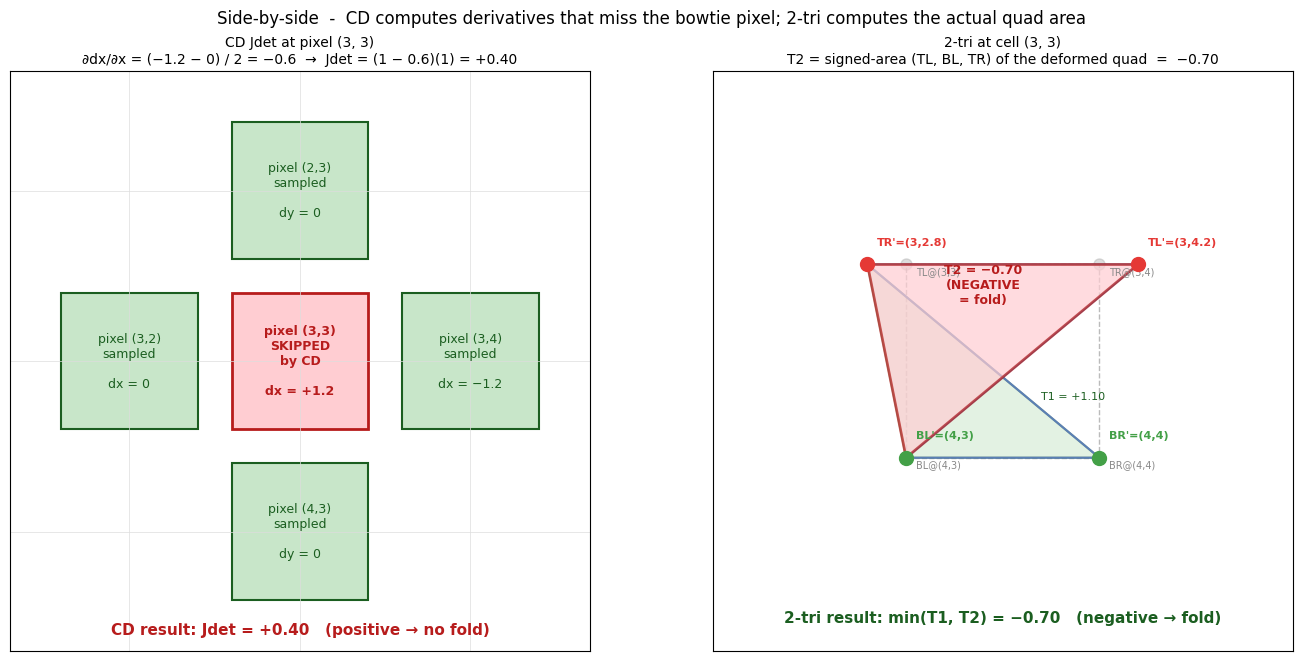

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), layout='constrained')

# --- LEFT: CD stencil with values -----------------------------------
ax = axes[0]
ax.set_xlim(1.3, 4.7); ax.set_ylim(4.7, 1.3)
ax.set_aspect('equal')
ax.set_title('CD Jdet at pixel (3, 3)\n'
             '∂dx/∂x = (−1.2 − 0) / 2 = −0.6  →  Jdet = (1 − 0.6)(1) = +0.40',
             fontsize=10)
for x in range(2, 5):
    ax.axvline(x, color='#dddddd', lw=0.5)
for y in range(2, 5):
    ax.axhline(y, color='#dddddd', lw=0.5)
# Center pixel - skipped, has the bowtie value
ax.add_patch(Rectangle((2.6, 2.6), 0.8, 0.8, facecolor='#ffcdd2', edgecolor='#b71c1c', lw=2))
ax.text(3, 3, 'pixel (3,3)\nSKIPPED\nby CD\n\ndx = +1.2', ha='center', va='center', fontsize=9, color='#b71c1c', weight='bold')
# Neighbours
ax.add_patch(Rectangle((1.6, 2.6), 0.8, 0.8, facecolor='#c8e6c9', edgecolor='#1b5e20', lw=1.5))
ax.text(2, 3, 'pixel (3,2)\nsampled\n\ndx = 0', ha='center', va='center', fontsize=9, color='#1b5e20')
ax.add_patch(Rectangle((3.6, 2.6), 0.8, 0.8, facecolor='#c8e6c9', edgecolor='#1b5e20', lw=1.5))
ax.text(4, 3, 'pixel (3,4)\nsampled\n\ndx = −1.2', ha='center', va='center', fontsize=9, color='#1b5e20')
ax.add_patch(Rectangle((2.6, 1.6), 0.8, 0.8, facecolor='#c8e6c9', edgecolor='#1b5e20', lw=1.5))
ax.text(3, 2, 'pixel (2,3)\nsampled\n\ndy = 0', ha='center', va='center', fontsize=9, color='#1b5e20')
ax.add_patch(Rectangle((2.6, 3.6), 0.8, 0.8, facecolor='#c8e6c9', edgecolor='#1b5e20', lw=1.5))
ax.text(3, 4, 'pixel (4,3)\nsampled\n\ndy = 0', ha='center', va='center', fontsize=9, color='#1b5e20')
ax.set_xticks([]); ax.set_yticks([])
ax.text(3, 4.6, 'CD result: Jdet = +0.40   (positive → no fold)',
        ha='center', fontsize=11, color='#b71c1c', weight='bold')

# --- RIGHT: 2-tri at cell (3, 3) -------------------------------------
ax = axes[1]
ax.set_xlim(2, 5); ax.set_ylim(5, 2)
ax.set_aspect('equal')
ax.set_title('2-tri at cell (3, 3)\n'
             'T2 = signed-area (TL, BL, TR) of the deformed quad  =  −0.70',
             fontsize=10)
# Original cell corners (faded)
for (yy, xx, lbl) in [(3, 3, 'TL'), (3, 4, 'TR'), (4, 3, 'BL'), (4, 4, 'BR')]:
    ax.plot(xx, yy, 'o', color='#aaaaaa', markersize=8, alpha=0.4)
    ax.text(xx + 0.05, yy + 0.05, f'{lbl}@({yy},{xx})', fontsize=7, color='#888888')
# Original cell rectangle
ax.add_patch(Rectangle((3, 3), 1, 1, fill=False, edgecolor='#bbbbbb', lw=1, linestyle='--'))
# Deformed corners
TL = (3, 4.2); TR = (3, 2.8); BL = (4, 3); BR = (4, 4)
for (yy, xx, lbl, col) in [(TL[0], TL[1], 'TL', '#e53935'), (TR[0], TR[1], 'TR', '#e53935'),
                            (BL[0], BL[1], 'BL', '#43a047'), (BR[0], BR[1], 'BR', '#43a047')]:
    ax.plot(xx, yy, 'o', color=col, markersize=10, zorder=3)
    ax.text(xx + 0.05, yy - 0.1, f"{lbl}'=({yy},{xx})", fontsize=8, color=col, weight='bold')
# Deformed quad outline
px = [TL[1], TR[1], BR[1], BL[1], TL[1]]; py = [TL[0], TR[0], BR[0], BL[0], TL[0]]
ax.plot(px, py, color='#5b7fb5', lw=1.5)
# T2 triangle (negative-area one): TL, BL, TR
t2_x = [TL[1], BL[1], TR[1]]; t2_y = [TL[0], BL[0], TR[0]]
ax.add_patch(Polygon(list(zip(t2_x, t2_y)), facecolor='#ffcdd2', edgecolor='#b71c1c', lw=2, alpha=0.7, zorder=2))
ax.text(3.4, 3.2, 'T2 = −0.70\n(NEGATIVE\n= fold)', fontsize=9, color='#b71c1c', weight='bold', ha='center')
# T1 triangle (positive): TR, BL, BR
t1_x = [TR[1], BL[1], BR[1]]; t1_y = [TR[0], BL[0], BR[0]]
ax.add_patch(Polygon(list(zip(t1_x, t1_y)), facecolor='#c8e6c9', edgecolor='#1b5e20', lw=1.5, alpha=0.5, zorder=1))
ax.text(3.7, 3.7, 'T1 = +1.10', fontsize=8, color='#1b5e20')
ax.set_xticks([]); ax.set_yticks([])
ax.text(3.5, 4.85, '2-tri result: min(T1, T2) = −0.70   (negative → fold)',
        ha='center', fontsize=11, color='#1b5e20', weight='bold')

plt.suptitle('Side-by-side  -  CD computes derivatives that miss the bowtie pixel; '
             '2-tri computes the actual quad area',
             fontsize=12)
plt.show()

## 4. The averaging problem in 1D

Plot `dx[3, :]` — the displacement profile along row 3. The bowtie is two consecutive opposite spikes:

```
x:        0    1    2    3    4    5    6
dx[3,x]:  0    0    0   +1.2 −1.2  0    0
```

**Forward differences** (1-pixel stride) between adjacent samples:

- between `x=3` and `x=4`:  `Δdx = −2.4`  ←  the offending jump
- everywhere else:  small or zero

**Central differences** (2-pixel stride) at each pixel:

- at `x = 3`: `(dx[4] − dx[2]) / 2 = (−1.2 − 0) / 2 = −0.6`
- at `x = 4`: `(dx[5] − dx[3]) / 2 = (0 − 1.2) / 2 = −0.6`

CD's stride straddles the offending jump and averages the `+1.2 → 0` slope (left side, magnitude `0.6`) with the `0 → −1.2` slope (right side, magnitude `0.6`). Both yield `−0.6`. The `Δdx = −2.4` jump *between* the two samples — the actual fold — never enters either pixel's CD computation.

The figure plots all three: the raw `dx` profile, the FD slopes (large-magnitude spike at the fold), and the CD slopes (smooth, no spike).

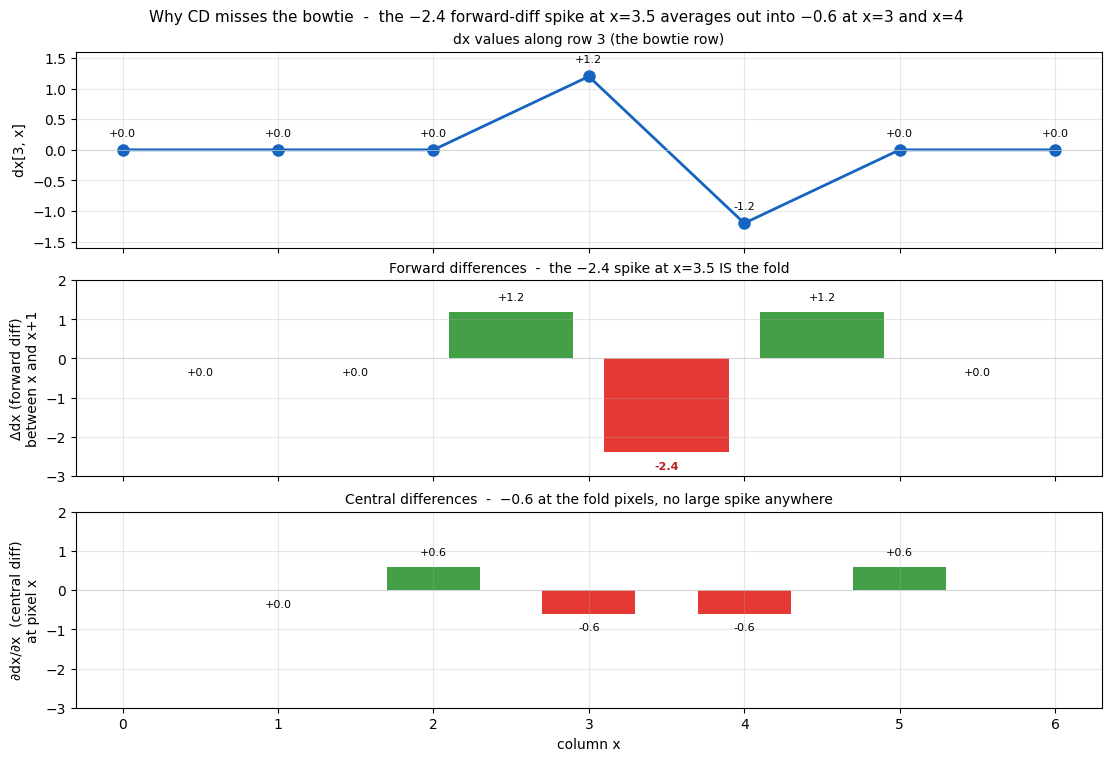

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), layout='constrained', sharex=True)

x_grid = np.arange(W)
dx_row = phi[1, 3, :]

# Forward differences (between adjacent samples, sampled at midpoints)
fd = np.diff(dx_row)
fd_x = x_grid[:-1] + 0.5

# Central differences at each interior pixel
cd = np.zeros_like(dx_row, dtype=float)
cd[1:-1] = (dx_row[2:] - dx_row[:-2]) / 2.0

# --- Panel 1: dx profile --------------------------------------------
ax = axes[0]
ax.plot(x_grid, dx_row, '-o', color='#1565c0', lw=2, markersize=8)
ax.axhline(0, color='#cccccc', lw=0.5)
ax.set_ylabel('dx[3, x]')
ax.set_title('dx values along row 3 (the bowtie row)', fontsize=10)
for x in x_grid:
    ax.annotate(f'{dx_row[x]:+.1f}', (x, dx_row[x]), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)
ax.set_ylim(-1.6, 1.6)
ax.grid(alpha=0.3)

# --- Panel 2: forward differences ----------------------------------
ax = axes[1]
ax.bar(fd_x, fd, width=0.8, color=['#e53935' if v < 0 else '#43a047' for v in fd])
ax.axhline(0, color='#cccccc', lw=0.5)
ax.set_ylabel('Δdx (forward diff)\nbetween x and x+1')
ax.set_title('Forward differences  -  the −2.4 spike at x=3.5 IS the fold', fontsize=10)
for xx, vv in zip(fd_x, fd):
    ax.annotate(f'{vv:+.1f}', (xx, vv), textcoords='offset points',
                xytext=(0, 8 if vv > 0 else -12), ha='center', fontsize=8,
                color='#b71c1c' if vv < -1 else 'black',
                weight='bold' if vv < -1 else 'normal')
ax.set_ylim(-3, 2)
ax.grid(alpha=0.3)

# --- Panel 3: central differences -----------------------------------
ax = axes[2]
colors = ['#e53935' if v < 0 else '#43a047' for v in cd]
ax.bar(x_grid[1:-1], cd[1:-1], width=0.6, color=colors[1:-1])
ax.axhline(0, color='#cccccc', lw=0.5)
ax.set_xlabel('column x')
ax.set_ylabel('∂dx/∂x  (central diff)\nat pixel x')
ax.set_title('Central differences  -  −0.6 at the fold pixels, no large spike anywhere', fontsize=10)
for xx in x_grid[1:-1]:
    ax.annotate(f'{cd[xx]:+.1f}', (xx, cd[xx]), textcoords='offset points',
                xytext=(0, 8 if cd[xx] > 0 else -12), ha='center', fontsize=8)
ax.set_ylim(-3, 2)
ax.set_xticks(x_grid)
ax.grid(alpha=0.3)

plt.suptitle(
    'Why CD misses the bowtie  -  the −2.4 forward-diff spike at x=3.5 averages out into −0.6 at x=3 and x=4',
    fontsize=11)
plt.show()

## 5. Subpixel-fold geometry

Zoom into the bowtie cell `(3, 3)`. Plot the original square in dashed grey and the deformed quad in solid blue. Vertices that swapped horizontally are highlighted in red and connected with dashed arrows showing where they moved.

The deformed quad has a *self-intersection* — the top-left and top-right corners swapped sides — so it is no longer a simple polygon. The 2-tri diagonal splits it into two triangles, exactly one of which has negative signed area (because traversing its three vertices in the original `TL → BL → TR` order is now clockwise instead of counter-clockwise). That sign flip is the fold detection.

The geometric reality being captured:

- Vertex `TL = (3, 3)` moved to `(3, 4.2)`. Originally on the *left* of the cell, now on the *right*.
- Vertex `TR = (3, 4)` moved to `(3, 2.8)`. Originally on the *right*, now on the *left*.
- They crossed each other. The cell's top edge has reversed orientation.

This is what "subpixel fold" means: within a single 1×1 cell, the displacement field varies by enough to swap the order of two adjacent vertices. Any check that only looks at *neighbour-averaged* derivatives (CD) can miss it. A check that looks at the *actual deformed quad shape* (2-tri) catches it directly.

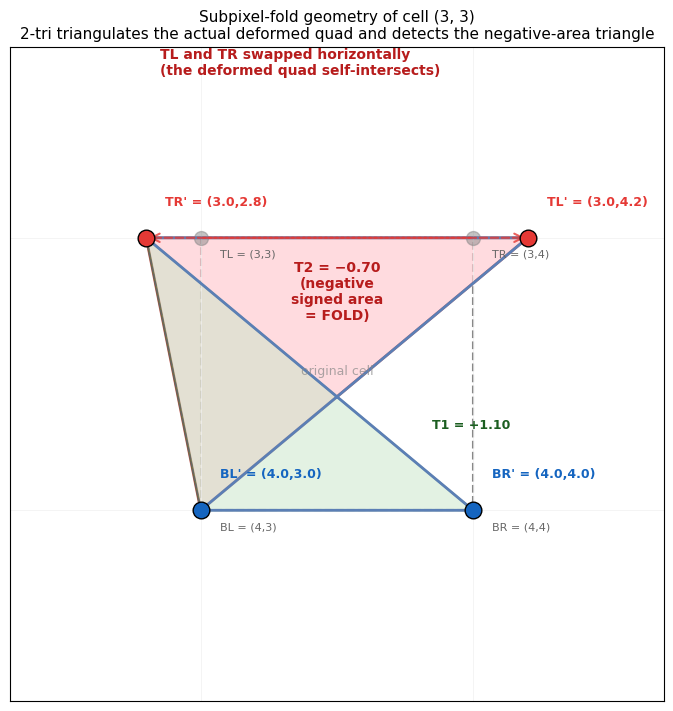

In [7]:
fig, ax = plt.subplots(figsize=(10, 7), layout='constrained')

# Background grid (zoomed to bowtie region)
for x in range(2, 6):
    ax.plot([x, x], [2, 5], color='#f0f0f0', lw=0.5)
for y in range(2, 6):
    ax.plot([2, 5], [y, y], color='#f0f0f0', lw=0.5)

# Original cell (3, 3)
ax.add_patch(Rectangle((3, 3), 1, 1, fill=False, edgecolor='#888888', lw=1.5, linestyle='--'))
ax.text(3.5, 3.5, 'original cell', ha='center', fontsize=9, color='#888888', alpha=0.7)

# Original corner positions (lattice)
orig = {'TL': (3, 3), 'TR': (3, 4), 'BL': (4, 3), 'BR': (4, 4)}
for lbl, (yy, xx) in orig.items():
    ax.plot(xx, yy, 'o', color='#888888', markersize=10, alpha=0.5)
    ax.text(xx + 0.07, yy + 0.07, f'{lbl} = ({yy},{xx})', fontsize=8, color='#666666')

# Deformed corners
deformed = {'TL': (3, 4.2), 'TR': (3, 2.8), 'BL': (4, 3), 'BR': (4, 4)}
color_def = {'TL': '#e53935', 'TR': '#e53935', 'BL': '#1565c0', 'BR': '#1565c0'}
for lbl, (yy, xx) in deformed.items():
    ax.plot(xx, yy, 'o', color=color_def[lbl], markersize=12, zorder=4, markeredgecolor='black')
    ax.text(xx + 0.07, yy - 0.12, f"{lbl}' = ({yy:.1f},{xx:.1f})", fontsize=9, color=color_def[lbl], weight='bold')

# Movement arrows for the swapped vertices
for lbl in ['TL', 'TR']:
    ox, oy = orig[lbl][1], orig[lbl][0]
    dx_, dy_ = deformed[lbl][1], deformed[lbl][0]
    ax.add_patch(FancyArrowPatch((ox, oy), (dx_, dy_),
                                  arrowstyle='->', color='#e53935',
                                  lw=1.5, linestyle='--', mutation_scale=15, alpha=0.8, zorder=3))

# Deformed quad outline (drawing in TL, TR, BR, BL order to show the bowtie)
px = [deformed['TL'][1], deformed['TR'][1], deformed['BR'][1], deformed['BL'][1], deformed['TL'][1]]
py = [deformed['TL'][0], deformed['TR'][0], deformed['BR'][0], deformed['BL'][0], deformed['TL'][0]]
ax.plot(px, py, color='#5b7fb5', lw=2.0, zorder=2)

# T2 triangle (TL, BL, TR) - the negative one
t2_x = [deformed['TL'][1], deformed['BL'][1], deformed['TR'][1]]
t2_y = [deformed['TL'][0], deformed['BL'][0], deformed['TR'][0]]
ax.add_patch(Polygon(list(zip(t2_x, t2_y)), facecolor='#ffcdd2', edgecolor='#b71c1c',
                      lw=2, alpha=0.7, zorder=1))
ax.text(3.5, 3.3, 'T2 = −0.70\n(negative\nsigned area\n= FOLD)',
        ha='center', fontsize=10, color='#b71c1c', weight='bold', zorder=5)

# T1 triangle (TR, BL, BR) - the positive one
t1_x = [deformed['TR'][1], deformed['BL'][1], deformed['BR'][1]]
t1_y = [deformed['TR'][0], deformed['BL'][0], deformed['BR'][0]]
ax.add_patch(Polygon(list(zip(t1_x, t1_y)), facecolor='#c8e6c9', edgecolor='#1b5e20',
                      lw=1.5, alpha=0.5, zorder=1))
ax.text(3.85, 3.7, 'T1 = +1.10', fontsize=9, color='#1b5e20', weight='bold')

# Diagonal
ax.plot([deformed['TR'][1], deformed['BL'][1]],
        [deformed['TR'][0], deformed['BL'][0]],
        '--', color='#666666', lw=1, zorder=2)

# Annotations
ax.text(2.85, 2.4, 'TL and TR swapped horizontally\n(the deformed quad self-intersects)',
        fontsize=10, color='#b71c1c', weight='bold')

ax.set_xlim(2.3, 4.7)
ax.set_ylim(4.7, 2.3)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Subpixel-fold geometry of cell (3, 3)\n'
             '2-tri triangulates the actual deformed quad and detects the negative-area triangle',
             fontsize=11)
plt.show()

## 6. Continuum view — J is a continuous function inside each cell

Lattice samples define a *continuous* deformation field by interpolation. Under bilinear interpolation (the standard choice for image-grid displacement fields), every interior point `(s, t) ∈ [0, 1]²` of cell `(cy, cx)` has a well-defined deformed position and a well-defined Jacobian determinant

$$
J(s, t) \;=\; \det\!\begin{bmatrix} \partial y_{\text{def}}/\partial s & \partial y_{\text{def}}/\partial t \\ \partial x_{\text{def}}/\partial s & \partial x_{\text{def}}/\partial t \end{bmatrix}.
$$

The cell is folded *somewhere* iff `J(s, t) < 0` for some interior `(s, t)`. The fold is not localised at a single lattice vertex — it occupies a *region* of the cell, bounded by the contour `J = 0`.

The figure below plots `J(s, t)` over the bowtie cell `(3, 3)`. The deformation has `dx[3, 3] = +1.2`, `dx[3, 4] = −1.2`, all other corner displacements zero, which yields the closed-form `J(s, t) = −1.4 + 2.4 s` (the cell's J depends only on the row coordinate `s`). The contour `J = 0` at `s ≈ 0.583` separates the upper *fold region* from the lower *orientation-preserving region*. Roughly 58 % of the cell's area is folded.

**This is the geometrically correct picture of what "the cell is folded" means:** a sub-region of the cell where the local linearisation of the deformation has flipped orientation. Any folding-detection method must answer the question *"does this cell contain such a region?"*

cell (3, 3):  bilinear J range = [-1.400, +1.000]
              fold area (J <= 0) = 58% of the cell


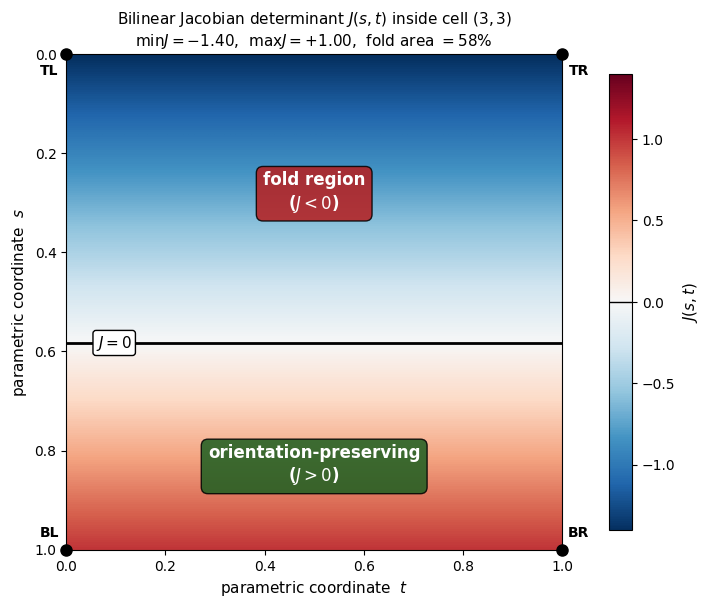

In [8]:
def bilinear_jacobian_over_cell(phi, cy, cx, S=121):
    """Bilinear-interpolated Jacobian determinant J(s, t) over cell (cy, cx).

    Returns SS, TT (parametric grids), J (Jacobian array), Y_def, X_def
    (deformed coordinates of each sub-grid point).
    """
    dy_TL, dx_TL = phi[0, cy, cx],     phi[1, cy, cx]
    dy_TR, dx_TR = phi[0, cy, cx + 1], phi[1, cy, cx + 1]
    dy_BL, dx_BL = phi[0, cy + 1, cx], phi[1, cy + 1, cx]
    dy_BR, dx_BR = phi[0, cy + 1, cx + 1], phi[1, cy + 1, cx + 1]

    ss = np.linspace(0, 1, S)
    tt = np.linspace(0, 1, S)
    SS, TT = np.meshgrid(ss, tt, indexing='ij')

    # Partials of the bilinear interpolation
    ddyds = -(1 - TT) * dy_TL - TT * dy_TR + (1 - TT) * dy_BL + TT * dy_BR
    ddydt = -(1 - SS) * dy_TL + (1 - SS) * dy_TR - SS * dy_BL + SS * dy_BR
    ddxds = -(1 - TT) * dx_TL - TT * dx_TR + (1 - TT) * dx_BL + TT * dx_BR
    ddxdt = -(1 - SS) * dx_TL + (1 - SS) * dx_TR - SS * dx_BL + SS * dx_BR

    # The map is (s, t) -> (cy + s + dy(s,t), cx + t + dx(s,t)).
    dyds = 1 + ddyds
    dydt = ddydt
    dxds = ddxds
    dxdt = 1 + ddxdt

    J = dyds * dxdt - dydt * dxds

    # Deformed positions
    dy_st = ((1 - SS) * (1 - TT) * dy_TL + (1 - SS) * TT * dy_TR
             + SS * (1 - TT) * dy_BL + SS * TT * dy_BR)
    dx_st = ((1 - SS) * (1 - TT) * dx_TL + (1 - SS) * TT * dx_TR
             + SS * (1 - TT) * dx_BL + SS * TT * dx_BR)
    Y_def = cy + SS + dy_st
    X_def = cx + TT + dx_st

    return SS, TT, J, Y_def, X_def


SS, TT, J_cont, Y_def, X_def = bilinear_jacobian_over_cell(phi, 3, 3, S=121)
fold_fraction = float((J_cont <= 0).mean())
print(f'cell (3, 3):  bilinear J range = [{J_cont.min():+.3f}, {J_cont.max():+.3f}]')
print(f'              fold area (J <= 0) = {100 * fold_fraction:.0f}% of the cell')

# Single-panel manuscript figure: J(s, t) heatmap with J=0 contour.
fig, ax = plt.subplots(figsize=(7, 6.5), layout='constrained')

vmax = max(abs(J_cont).max(), 1.0)
im = ax.imshow(J_cont, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[0, 1, 1, 0], aspect='equal', interpolation='bilinear')
cs = ax.contour(TT, SS, J_cont, levels=[0], colors='black', linewidths=2.0)

# Inline contour label
ax.text(0.06, 0.583, '$J = 0$', fontsize=11, color='black', va='center',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))

# Region labels
ax.text(0.5, 0.28, 'fold region\n($J < 0$)', ha='center', va='center',
        fontsize=12, color='white', weight='bold',
        bbox=dict(facecolor='#b71c1c', alpha=0.85, edgecolor='black', boxstyle='round,pad=0.4'))
ax.text(0.5, 0.83, 'orientation-preserving\n($J > 0$)', ha='center', va='center',
        fontsize=12, color='white', weight='bold',
        bbox=dict(facecolor='#1b5e20', alpha=0.85, edgecolor='black', boxstyle='round,pad=0.4'))

# Corner labels
for (s_, t_, lbl, off) in [(0, 0, 'TL', (-1, -1)), (0, 1, 'TR', (1, -1)),
                            (1, 0, 'BL', (-1, 1)),  (1, 1, 'BR', (1, 1))]:
    ax.plot(t_, s_, 'o', color='black', markersize=8, clip_on=False, zorder=5)
    ax.annotate(lbl, (t_, s_), xytext=(off[0] * 12, off[1] * 12),
                textcoords='offset points', fontsize=10, weight='bold',
                ha='center', va='center')

ax.set_xlabel('parametric coordinate  $t$', fontsize=11)
ax.set_ylabel('parametric coordinate  $s$', fontsize=11)
ax.set_title('Bilinear Jacobian determinant $J(s,t)$ inside cell $(3,3)$\n'
             f'$\\min J = {J_cont.min():+.2f}$,  '
             f'$\\max J = {J_cont.max():+.2f}$,  '
             f'fold area $= {100 * fold_fraction:.0f}\\%$', fontsize=11)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$J(s, t)$', fontsize=11)
cbar.ax.axhline(0, color='black', lw=1.0)

plt.show()

## 7. How each method discretises the continuous J

Every fold check on a discrete grid is, implicitly, a discretisation of the continuous Jacobian field shown above. The three methods discretise it in different ways:

- **Continuous (ground truth).** `J(s, t)` evaluated at every interior point of the cell. This is what fold detection is *really* asking about; it's not directly computable from lattice samples without an interpolation choice.
- **Two-triangle check (piecewise-linear).** Splits the cell along its `(TR, BL)` diagonal into two sub-triangles. Replaces the continuous `J(s, t)` with the piecewise-constant Jacobian of the affine map that interpolates each sub-triangle's three vertex displacements — equivalently, twice the signed area of each deformed sub-triangle. Two scalar values per cell. Captures the existence of a fold whenever the piecewise-linear and bilinear interpolants disagree on sign over the same triangle, which on the bowtie is exactly the case.
- **Central differences (per-vertex).** Estimates partial derivatives at each *lattice vertex* using neighbouring lattice values. Produces one scalar per vertex, none of which is anchored to any cell. The cell interior — the actual locus of the fold — is *uninstantiated*; CD has no opinion about what is happening inside it.

The figure below puts the three side by side. Same cell, same continuous truth, three projections."

cell (3, 3):  T1 = +0.500   T2 = -0.700
              piecewise-linear J:  T1 -> +1.00,  T2 -> -1.40


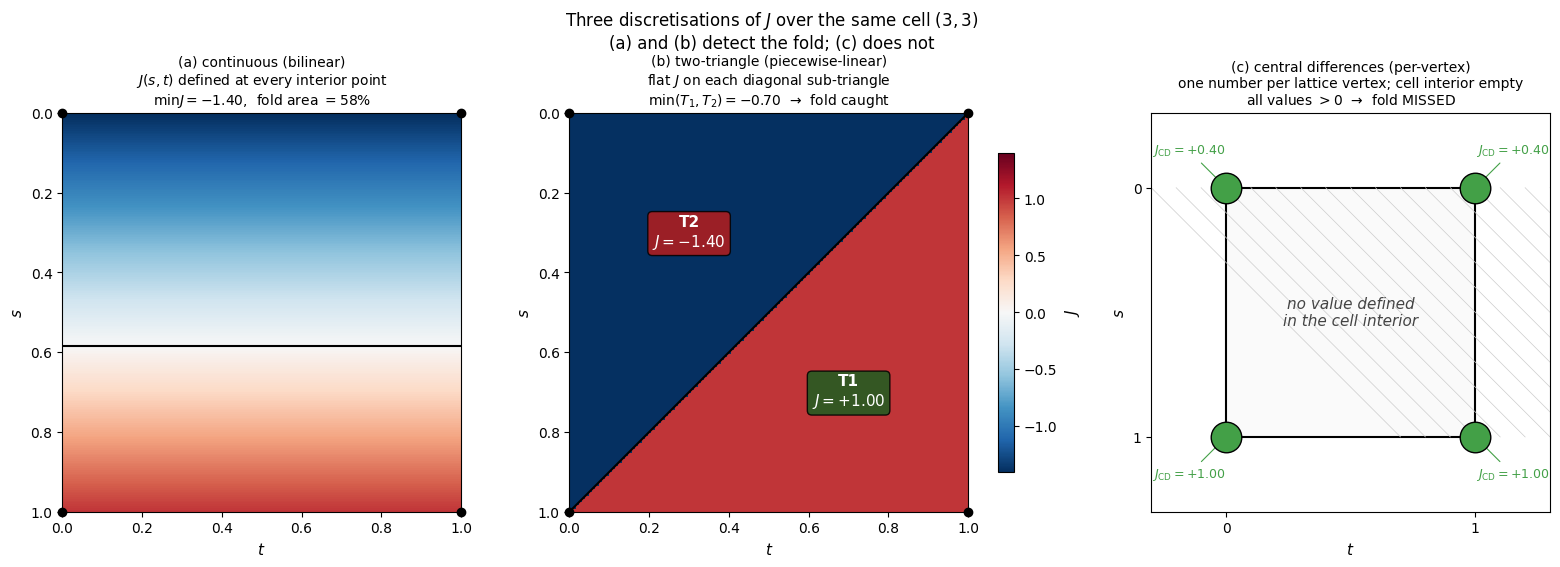

In [9]:
T1_val = float(T1[3, 3])
T2_val = float(T2[3, 3])
print(f'cell (3, 3):  T1 = {T1_val:+.3f}   T2 = {T2_val:+.3f}')
# The piecewise-linear (affine-per-triangle) Jacobian over each half-cell
J_pl_T1 = 2.0 * T1_val   # affine-Jacobian = 2 * signed-area on a unit half-cell
J_pl_T2 = 2.0 * T2_val
print(f'              piecewise-linear J:  T1 -> {J_pl_T1:+.2f},  T2 -> {J_pl_T2:+.2f}')

vmax = max(abs(J_cont).max(), abs(J_pl_T1), abs(J_pl_T2), 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), layout='constrained')

# ---------------- Panel (a): continuous bilinear J ------------------
ax = axes[0]
ax.imshow(J_cont, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
          extent=[0, 1, 1, 0], aspect='equal', interpolation='bilinear')
ax.contour(TT, SS, J_cont, levels=[0], colors='black', linewidths=1.5)
ax.set_xlabel('$t$', fontsize=11); ax.set_ylabel('$s$', fontsize=11)
ax.set_title('(a) continuous (bilinear)\n'
             '$J(s, t)$ defined at every interior point\n'
             f'$\\min J = {J_cont.min():+.2f}$,  fold area $= {100*fold_fraction:.0f}\\%$',
             fontsize=10)
# Corner ticks
for (s_, t_, lbl) in [(0, 0, 'TL'), (0, 1, 'TR'), (1, 0, 'BL'), (1, 1, 'BR')]:
    ax.plot(t_, s_, 'o', color='black', markersize=6, clip_on=False, zorder=5)

# ---------------- Panel (b): 2-tri piecewise-linear ----------------
ax = axes[1]
# Build a piecewise-constant J over the parametric square split along (TR, BL).
# Diagonal goes from (s=0, t=1) to (s=1, t=0), i.e. s + t = 1.
# Convention: T1 covers s + t > 1 (BR side); T2 covers s + t < 1 (TL side).
J_pl_grid = np.where(SS + TT > 1, J_pl_T1, J_pl_T2)
ax.imshow(J_pl_grid, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
          extent=[0, 1, 1, 0], aspect='equal', interpolation='nearest')
# Diagonal
ax.plot([0, 1], [1, 0], '-', color='black', lw=1.5)
# T1 / T2 labels with their values
ax.text(0.7, 0.7, f'T1\n$J = {J_pl_T1:+.2f}$',
        ha='center', va='center', fontsize=11, weight='bold', color='white',
        bbox=dict(facecolor='#1b5e20', alpha=0.85, edgecolor='black', boxstyle='round,pad=0.3'))
ax.text(0.3, 0.3, f'T2\n$J = {J_pl_T2:+.2f}$',
        ha='center', va='center', fontsize=11, weight='bold', color='white',
        bbox=dict(facecolor='#b71c1c', alpha=0.85, edgecolor='black', boxstyle='round,pad=0.3'))
ax.set_xlabel('$t$', fontsize=11); ax.set_ylabel('$s$', fontsize=11)
ax.set_title('(b) two-triangle (piecewise-linear)\n'
             'flat $J$ on each diagonal sub-triangle\n'
             f'$\\min(T_1, T_2) = {min(T1_val, T2_val):+.2f}$  →  fold caught',
             fontsize=10)
for (s_, t_, lbl) in [(0, 0, 'TL'), (0, 1, 'TR'), (1, 0, 'BL'), (1, 1, 'BR')]:
    ax.plot(t_, s_, 'o', color='black', markersize=6, clip_on=False, zorder=5)

# ---------------- Panel (c): CD per-vertex --------------------------
ax = axes[2]
ax.set_xlim(-0.3, 1.3); ax.set_ylim(1.3, -0.3)
ax.set_aspect('equal')

# Empty interior - nothing to draw
ax.add_patch(Rectangle((0, 0), 1, 1, fill=True, facecolor='#fafafa',
                        edgecolor='black', lw=1.5, zorder=1))

# Diagonal hatching to indicate "no information"
xs = np.linspace(0, 1, 30)
for x0 in np.linspace(-0.3, 1.6, 20):
    ax.plot([x0, x0 + 1], [0, 1], color='#cccccc', lw=0.5, zorder=2)

ax.text(0.5, 0.5, 'no value defined\nin the cell interior',
        ha='center', va='center', fontsize=11, style='italic', color='#444444', zorder=3)

# CD Jdet at the 4 corners
cd_corner = {(0, 0): jd_cd[3, 3], (0, 1): jd_cd[3, 4], (1, 0): jd_cd[4, 3], (1, 1): jd_cd[4, 4]}
for (s_, t_), val in cd_corner.items():
    col = '#43a047' if val > 0 else '#e53935'
    ax.plot(t_, s_, 'o', color=col, markersize=22,
            markeredgecolor='black', zorder=5)
    # Position label outside the cell
    dx_lbl = -0.15 if t_ == 0 else 0.15
    dy_lbl = -0.15 if s_ == 0 else 0.15
    ax.annotate(f'$J_{{\\rm CD}} = {val:+.2f}$', (t_, s_),
                xytext=(t_ + dx_lbl, s_ + dy_lbl),
                ha='center', va='center', fontsize=9, weight='bold',
                color=col,
                arrowprops=dict(arrowstyle='-', color=col, lw=0.8))

ax.set_xlabel('$t$', fontsize=11); ax.set_ylabel('$s$', fontsize=11)
ax.set_title('(c) central differences (per-vertex)\n'
             'one number per lattice vertex; cell interior empty\n'
             'all values $> 0$  →  fold MISSED', fontsize=10)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

# Single colorbar for panels (a) and (b)
cbar = fig.colorbar(axes[0].images[0], ax=axes[:2], fraction=0.046, pad=0.02,
                     orientation='vertical', shrink=0.8)
cbar.set_label('$J$', fontsize=11)

plt.suptitle('Three discretisations of $J$ over the same cell $(3,3)$\n'
             '(a) and (b) detect the fold; (c) does not',
             fontsize=12)
plt.show()

## 8. The deformed cell as a continuous geometric object

Sampling the bilinear interpolation densely inside the original cell and plotting the deformed positions makes the fold a *visible geometric object*: a region of the deformed image where the cell's interior wraps over itself. The fold boundary (`J = 0`) is the curve where the deformation locally collapses area to zero — geometrically the *locus of the self-intersection*.

The figure below shows the cell as a fine grid of sub-points, deformed under the bilinear interpolation. Each point is coloured by the local `J` value at its parametric source, with the `J = 0` contour highlighted. The bowtie is no longer four discrete vertices — it is a continuous shape whose interior covers the same image region twice (once with `J > 0`, once with `J < 0`), and the lattice-vertex geometry of section 5 is just the boundary of this continuous picture.

This is the cleanest formulation of *why two-tri sees the fold*: the signed area of each piecewise-linear sub-triangle is a finite-volume sample of the continuous `J` integral over that sub-triangle, and any sub-triangle that overlaps the `J < 0` region inherits a negative contribution. CD's per-vertex finite differences sample no region at all — they cannot distinguish an undisturbed cell from a cell with a 58 %-area fold inside it as long as the lattice-corner lookups happen to average positive.

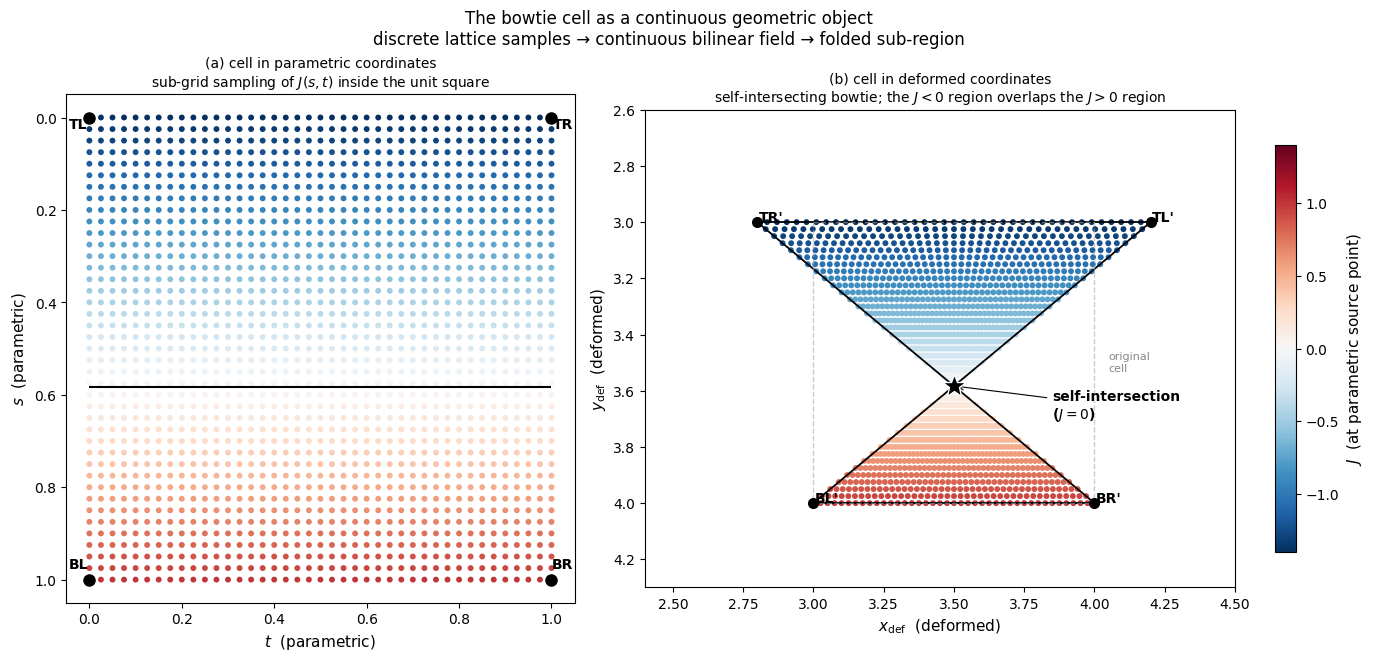

In [10]:
SS_d, TT_d, J_d, Y_d, X_d = bilinear_jacobian_over_cell(phi, 3, 3, S=41)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), layout='constrained')

vmax = max(abs(J_d).max(), 1.0)

# ---------------- Panel (a): parametric coordinates -----------------
ax = axes[0]
ax.scatter(TT_d.ravel(), SS_d.ravel(), c=J_d.ravel(),
           cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=18, edgecolors='none')
ax.contour(TT_d, SS_d, J_d, levels=[0], colors='black', linewidths=1.5)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_xlim(-0.05, 1.05); ax.set_ylim(1.05, -0.05)
for (s_, t_, lbl) in [(0, 0, 'TL'), (0, 1, 'TR'), (1, 0, 'BL'), (1, 1, 'BR')]:
    ax.plot(t_, s_, 'o', color='black', markersize=8, zorder=5)
    ax.annotate(lbl, (t_, s_), xytext=(8 * (1 if t_ == 1 else -1), 8 * (1 if s_ == 1 else -1)),
                textcoords='offset points', fontsize=10, weight='bold', ha='center')
ax.set_xlabel('$t$  (parametric)', fontsize=11)
ax.set_ylabel('$s$  (parametric)', fontsize=11)
ax.set_title('(a) cell in parametric coordinates\n'
             'sub-grid sampling of $J(s,t)$ inside the unit square', fontsize=10)

# ---------------- Panel (b): deformed coordinates -------------------
ax = axes[1]
sc = ax.scatter(X_d.ravel(), Y_d.ravel(), c=J_d.ravel(),
                cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=18, edgecolors='none')

# Draw the deformed cell boundary (top, right, bottom, left edges)
edge_top    = np.column_stack([X_d[0, :],  Y_d[0, :]])
edge_right  = np.column_stack([X_d[:, -1], Y_d[:, -1]])
edge_bottom = np.column_stack([X_d[-1, :], Y_d[-1, :]])
edge_left   = np.column_stack([X_d[:, 0],  Y_d[:, 0]])
for edge in (edge_top, edge_right, edge_bottom, edge_left):
    ax.plot(edge[:, 0], edge[:, 1], '-', color='black', lw=1.3)

# Self-intersection point (analytic)
ax.plot(3.5, 3 + 0.583, '*', color='black', markersize=18, zorder=6,
        markeredgecolor='white', markeredgewidth=1.0)
ax.annotate('self-intersection\n($J = 0$)', xy=(3.5, 3.583),
            xytext=(3.85, 3.7), fontsize=10, weight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# Original undeformed cell (faded reference)
orig_x = [3, 4, 4, 3, 3]; orig_y = [3, 3, 4, 4, 3]
ax.plot(orig_x, orig_y, '--', color='#aaaaaa', lw=1.0, alpha=0.6)
ax.text(4.05, 3.5, 'original\ncell', fontsize=8, color='#888888', va='center')

# Corner labels
deformed_corners = {'TL': (3, 4.2), 'TR': (3, 2.8), 'BL': (4, 3), 'BR': (4, 4)}
for lbl, (yy, xx) in deformed_corners.items():
    ax.plot(xx, yy, 'o', color='black', markersize=7, zorder=6)
    ax.annotate(lbl + "'", (xx, yy), xytext=(0.08, 0.08),
                textcoords='offset fontsize',
                fontsize=10, weight='bold')

ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_xlim(2.4, 4.5); ax.set_ylim(4.3, 2.6)
ax.set_xlabel('$x_{\\rm def}$  (deformed)', fontsize=11)
ax.set_ylabel('$y_{\\rm def}$  (deformed)', fontsize=11)
ax.set_title('(b) cell in deformed coordinates\n'
             'self-intersecting bowtie; the $J<0$ region overlaps the $J>0$ region', fontsize=10)

cbar = fig.colorbar(sc, ax=axes, fraction=0.022, pad=0.02, shrink=0.8)
cbar.set_label('$J$  (at parametric source point)', fontsize=11)

plt.suptitle('The bowtie cell as a continuous geometric object\n'
             'discrete lattice samples → continuous bilinear field → folded sub-region',
             fontsize=12)
plt.show()

## Summary — three reasons 2-tri beats CD

1. **CD's stencil skips the center pixel.** When CD computes Jdet at pixel `(cy, cx)` it uses the four cardinal neighbours and never reads `phi[cy, cx]` itself. A single-pixel anomaly — exactly what a subpixel fold looks like at the lattice level — is invisible at its own location. 2-tri's stencil is the four cell corners, every one of which contributes.
2. **CD's 2-pixel stride averages out 1-pixel jumps.** Forward differences would catch the bowtie's `−2.4` jump at `x = 3.5` directly; CD's stride straddles it and reports `−0.6` at *both* surrounding pixels. The constraint `(1 + ∂dx/∂x) > 0` then translates to `0.4 > 0` — positive, no fold flagged. The fold is real but lives in the *gap between* the CD samples.
3. **CD measures derivatives, 2-tri measures area.** The two formulations answer different questions. CD asks "is the local linearisation orientation-preserving?". 2-tri asks "does the deformed quad have positive signed area?". For smooth deformations they agree. For deformations that aren't smooth at the lattice scale — exactly the case the constraint is supposed to flag — only 2-tri gives the geometrically correct answer.

**Concrete numbers from this notebook (THRESHOLD = 0.01):**

| metric | min value on bowtie | n_neg | folds caught? |
|---|---:|---:|---|
| CD Jdet (per pixel) | `+0.40` | 0 | no |
| forward-diff `∂dx/∂x` (per gap) | `−2.4` (at x=3.5) | 1 | yes |
| 2-tri `min(T₁, T₂)` (per cell) | `−0.70` | 2 | yes (both folded cells) |

FD also catches the bowtie, but it's defined on *gaps* between pixels rather than on cells, which makes it awkward to use as a per-cell constraint. 2-tri is the natural per-cell geometric check: every quad cell of the deformed mesh must have positive area on both of its triangulations. That's exactly what the constraint `T₁ ≥ THRESHOLD ∧ T₂ ≥ THRESHOLD` enforces in `dvfopt.core.slsqp.iterative.iterative_serial` and friends.

The 2-tri check is also tighter: a deformation can have all positive Jdets *and still* fold (the bowtie); a deformation cannot have all positive triangle areas and fold, because positive areas are exactly the definition of "no fold". The 2-tri constraint is *both* the right physical question to ask ("is the mesh non-degenerate?") *and* sensitive enough to detect lattice-scale anomalies that CD averages away.